## 1. FourCastNet v2 colab 教學版

## 在colab中模擬虛擬環境 (請使用google中的colab)

### download FCNv2 couple model

*  step1: 連到自己的google雲端(方便拿取輸出結果)
*  step2: gdown下載FCNV2
*  step3: 下載FCNV2 模型權重變數
*  step4: 解壓縮並完成前置作業

In [1]:
from google.colab import drive
drive.mount('/content/drive')
## Step1: download FCNV2 code from github
!git clone https://github.com/yungyun0721/global_model_FCNV2_colab_education.git

## Step2: download FCNV2 weight
%cd /content/global_model_FCNV2_colab_education
!wget 'https://api.ngc.nvidia.com/v2/models/nvidia/modulus/modulus_fcnv2_sm/versions/v0.2/files/fcnv2_sm.zip'
!unzip fcnv2_sm.zip
!mv fcnv2_sm FCNV2_weight
!rm -rf fcnv2_sm.zip

Mounted at /content/drive
Retrieving folder contents
Retrieving folder 1NknDad9luKTrQzR_OV3g_MzoR9x36PbA FCNV1_precip_v1
Retrieving folder 1JKbSUWfiPYa8RG52S8rMCPqkvh0qYyio __pycache__
Processing file 12Pb8psrULOitarXpIwbqEIk00w_LiQPX inference_helper.cpython-310.pyc
Processing file 1BDzI_DwC21VTT5NeN6QPJ7tMjx6fOSyu inference_weather.cpython-310.pyc
Processing file 1ay9SWXT-34QfGJExte4L1lw_na8GnLAR afnonet.py
Processing file 13KB8kgCTCpmdeRC3T0FwpGMW10mQmNvw inference_helper.py
Retrieving folder 1zBZPU6a0K30cMXRjqR6ek23JPgcpvJq5 FCNV1_precip_v2
Retrieving folder 1Zr1GhijJSKZGrk1WZLmxRtfHY_Uxmlyu __pycache__
Processing file 1ivER9fVdtCWydyqF4Yg8ISAP0H9wFvno __init__.cpython-310.pyc
Processing file 16mqnBrLGw8GFXEFMaFS8TUjOZt5sPJp9 __init__.cpython-312.pyc
Processing file 1pHdz3PSspv8_ueSpTFelQ6NlhsLVv4Ut afno.cpython-310.pyc
Processing file 1AvzbYPuTsHS1gRY4bnf1cyDWYynRtc77 afno.cpython-312.pyc
Processing file 1GyNjulzgpGlKdTgryJcC3I_Tgc8j2973 fft.cpython-310.pyc
Processing file 1WYsvdK

### 建置FCNV2需要的環境
*  Step1: 下載各種packages (colab 沒有的環境)

In [2]:
# install the environment
!pip install torch_harmonics
!pip install ruamel.yaml
!pip install netcdf4 cfgrib pygrib
!pip install onnxruntime # if cpu
!pip install -U onnx onnxruntime-gpu # if gpu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 109.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for torch_harmonics: filename=torch_harmonics-0.8.0-py3-none-any.whl size=162234 sha256=929c6cee52e21030bc34e8947a017aea7c24f46465e4bd562995970e7bfc03e8
  Stored in directory: /root/.cache/pip/wheels/de/35/f6/520d03aca1fd51fda6281591e12d15bfee315dc12de5b0a4af
Successfully built torch_harmonics
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.9/119.9 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 48.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 145.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.8/17.8 MB 118.0 MB/s eta 0:00

### 下載initial 資料
#### 此次選用NCEP GFS的初始場 (僅有過去10天時間資料)

In [3]:
# download the initial condition ERA5 (2026042700)
%cd /content/global_model_FCNV2_colab_education
!python download_ERA5_from_google_for_model_input.py --scheduled-time 2024102600 --save-folder input_data
!python download_history_ncep_new.py --scheduled-time 2024102600 --save-folder input_data
!python download_IFS_new.py --scheduled-time 2024102600 --save-folder input_data

/content/couple_model
https://storage.googleapis.com/ecmwf-open-data/20250724/00z/ifs/0p25/oper/20250724000000-0h-oper-fc.grib2
finish 2025072400


### FCNV2資料展示 (可以跳過)

/content/couple_model


Text(0, 0.5, 'Latitude')

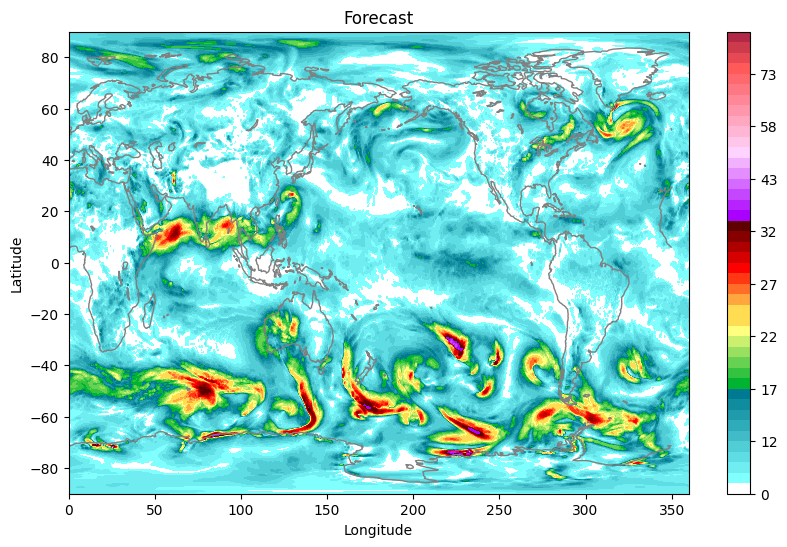

In [4]:
%cd /content/couple_model
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

# IC_data = np.load('/content/global_model_FCNV2_colab_education/input_data/ERA5_FCNV2_initial_condition.npy')
IC_data = np.load('/content/global_model_FCNV2_colab_education/input_data/IFS_initial_condition.npy')
# IC_data = np.load('/content/global_model_FCNV2_colab_education/input_data/ncep_initial_condition.npy')
IC_flip = np.flip(IC_data, axis=1)
# variables order (73 variables)
ordering = [ "10u",  "10v", "100u", "100v",  "2t",  "sp",  "msl", "tcwv",
        "u50",  "u100", "u150", "u200", "u250", "u300", "u400", "u500", "u600", "u700", "u850", "u925", "u1000",
        "v50",  "v100", "v150", "v200", "v250", "v300", "v400", "v500", "v600", "v700", "v850", "v925", "v1000",
        "z50",  "z100", "z150", "z200", "z250", "z300", "z400", "z500", "z600", "z700", "z850", "z925", "z1000",
        "t50",  "t100", "t150", "t200", "t250", "t300", "t400", "t500", "t600", "t700", "t850", "t925", "t1000",
        "r50",  "r100", "r150", "r200", "r250", "r300", "r400", "r500", "r600", "r700", "r850", "r925", "r1000"]
index_ordering = 18
# index_ordering = 15
wsp_lev = [0,4,6,8,10,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,34,36,38,40,43,46,49,52,55,58,61,64,67,70,73,76,79,82,85]
wsp_color = ['#ffffff','#80ffff','#6fedf1','#5fdde4','#50cdd5','#40bbc7','#2facba','#1f9bac','#108c9f','#007a92',\
            '#00b432','#33c341','#67d251','#99e060','#cbf06f','#ffff80','#ffdd52','#ffdc52','#ffa63e','#ff6d29','#ff3713','#ff0000','#d70000','#af0000','#870000','#5f0000',\
            '#aa00ff','#b722fe','#c446ff','#d46aff','#e38dff','#f1b1ff','#ffd3ff',\
            '#ffc6ea','#ffb6d5','#ffa6c1','#ff97ac','#ff8798','#fe7884','#ff696e','#ff595a','#e74954','#cc3a4c','#b22846','#9a1941']

coast = pd.read_csv('/content/couple_model/plot/coast.csv')
coast_lon = coast.lon_map.copy()
coast_lon[coast.lon_map<0]=coast.lon_map[coast.lon_map<0]+360
coast_lon[(coast.lon_map<0) & (coast.lon_map>=-10)]=np.nan
coast.lon_map = coast_lon
# lon lat 850 hpa windspeed
IC_for_plot = np.sqrt(IC_flip[index_ordering,:,:]**2+IC_flip[index_ordering+13,:,:]**2)
xx, yy = np.meshgrid(np.linspace(0,359.75,1440), np.linspace(-90, 90, 721))
plt.figure(figsize=(10,6))
plt.plot(coast.lon_map,coast.lat_map,color='gray',linewidth=1)
plt.contourf(xx, yy, IC_for_plot, levels=wsp_lev, colors=wsp_color)
# plt.contourf(xx, yy, IC_flip[57,:,:], cmap="rainbow", levels=np.linspace(210,315,43))
plt.title('Forecast')
plt.colorbar()
plt.xlabel('Longitude');plt.ylabel('Latitude')

### FCNV2預報
#### 目前使用GPU，預報240小時(每6小時一報)

In [5]:
# FCNV2 predicting
%cd /content/global_model_FCNV2_colab_education
!python inference_FCNV2.py --FCNV2_IC_path input_data/ERA5_FCNV2_initial_condition.npy --save_folder output_FCNV2_data --fore_hour 120 #--FCNV2_device cpu

/content/couple_model
initialize model ...
Model and weights are loaded.
/content/couple_model/FCNV2/fourcastnetv2/layers.py:623: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=False):
/content/couple_model/FCNV2/fourcastnetv2/layers.py:632: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=False):
finishing 1.0 days
finishing 2.0 days
finishing 3.0 days
finishing 4.0 days
finishing 5.0 days
finishing 6.0 days
finishing 7.0 days
finishing 8.0 days
finishing 9.0 days
finishing 10.0 days


### 預報完成後，查看結果
#### 進入plot底下，把850hPa的風場畫出

In [6]:
%cd /content/global_model_FCNV2_colab_education/plot/
!python plot850.py --data_source_file ../output_FCNV2_data --save_folder plot_850

/content/couple_model/plot
rm: cannot remove 'plot_figure_FCNV2': No such file or directory
files count: 41
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40


### 放到google雲端中方便下載

In [7]:
%cd /content/couple_model
import os
os.makedirs('/content/drive/MyDrive/FCNV2_result/', exist_ok=True)
!cp -rf plot/plot_figure_FCNV2 /content/drive/MyDrive/FCNV2_result/

/content/couple_model


## 2. 完成 FCNV2 預報後進行再加值
### run FCNV1_precip

In [8]:
# Step 1: download FCNV1 precip_v2 weight
!mkdir /content/global_model_FCNV2_colab_education/FCNV1_precip_v2/AFNOprecip_weight
%cd /content/global_model_FCNV2_colab_education/FCNV1_precip_v2/AFNOprecip_weight
!wget --content-disposition 'https://api.ngc.nvidia.com/v2/models/org/nvidia/team/earth-2/afno_dx_tp-v1-era5/v0.1.0/files?redirect=true&path=afno_precip.mdlus' --output-document 'afno_precip.mdlus'
!wget --content-disposition 'https://api.ngc.nvidia.com/v2/models/org/nvidia/team/earth-2/afno_dx_tp-v1-era5/v0.1.0/files?redirect=true&path=global_means.npy' --output-document 'global_means.npy'
!wget --content-disposition 'https://api.ngc.nvidia.com/v2/models/org/nvidia/team/earth-2/afno_dx_tp-v1-era5/v0.1.0/files?redirect=true&path=global_stds.npy' --output-document 'global_stds.npy'
!wget --content-disposition 'https://api.ngc.nvidia.com/v2/models/org/nvidia/team/earth-2/afno_dx_tp-v1-era5/v0.1.0/files?redirect=true&path=land_sea_mask.nc' --output-document 'land_sea_mask.nc'
!wget --content-disposition 'https://api.ngc.nvidia.com/v2/models/org/nvidia/team/earth-2/afno_dx_tp-v1-era5/v0.1.0/files?redirect=true&path=orography.nc' --output-document 'orography.nc'

/content/couple_model/FCNV1_precip_v2/AFNOprecip_weight
--2025-11-18 08:38:08--  https://api.ngc.nvidia.com/v2/models/org/nvidia/team/earth-2/afno_dx_tp-v1-era5/v0.1.0/files?redirect=true&path=afno_precip.mdlus
Resolving api.ngc.nvidia.com (api.ngc.nvidia.com)... 52.38.74.242, 44.228.50.133
Connecting to api.ngc.nvidia.com (api.ngc.nvidia.com)|52.38.74.242|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://xfiles.ngc.nvidia.com/org/nvidia/team/earth-2/models/afno_dx_tp-v1-era5/versions/v0.1.0/files/afno_precip.mdlus?ssec-algo=AES256&versionId=vJ03LbMRajDmzKwqBgIazdasMTTQXNKV&ssec-key=L3gYFEjYIajJ0FSWJmAGHkWq2zT7qFkLsPHKgEShzn1F5NF9xfhOpnsJ0iF%2FvAN1CyNKfA2vY2W9x57t%2BvbjHaUSSFQqxmpbrA%2FJkTS09Hw3m%2Bxk1XOJYZAwfa%2Fb0RNtyXvtp2dnnuB1Z%2FBBdF0TsxyXdfxjT%2BsxuQejZAjQPEzYHLcctDNv%2BBNoUHTRs1cUMQYz%2FRUXoHkb%2F94Cy8Oy2QFUEQ3%2FsjqjLJkdEGbEpMdp82bU%2FVFQhPKqW6i2PHvWrpv4gAJQP%2FYtOe%2BTg6jLo6%2FD5%2Fbu07VgnVnR8K5aIAGSqAqxFm6Wk0b%2BCMBeHR0kDspouUrPaTykeBUT2Cz

In [9]:
%cd /content/global_model_FCNV2_colab_education
!rm -rf output_FCNV1_precip_v2
!python inference_precip_v2.py --FCNV2_path output_FCNV2_data --IC_time 2025072400 --save_path output_FCNV1_precip_v2 --device cuda

/content/couple_model
/usr/local/lib/python3.12/dist-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
2025-07-24 00:00:00+00:00
finishing  output_precipitation_000h
2025-07-24 06:00:00+00:00
finishing  output_precipitation_006h
2025-07-24 12:00:00+00:00
finishing  output_precipitation_012h
2025-07-24 18:00:00+00:00
finishing  output_precipitation_018h
2025-07-25 00:00:00+00:00
finishing  output_precipitation_024h
2025-07-25 06:00:00+00:00
finishing  output_precipitation_030h
2025-07-25 12:00:00+00:00
finishing  output_precipitation_036h
2025-07-25 18:00:00+00:00
finishing  output_precipitation_042h
2025-07-26 00:00:00+00:00
finishing  output_precipitation_048h
2025-07-26 06:00:00+00:00
finishing  output_precipitation_054h
2025-07-26 12:00:00+00:00
fini

### 預報完成後，查看結果
#### 進入plot底下，把850hPa的風場畫出

In [14]:
%cd /content/couple_model/plot/
!rm -rf plot_figure_precip_v2
!python plot_precip_v2.py --data_source_file ../output_FCNV1_precip_v2 --save_folder plot_figure_precip_v2

/content/couple_model/plot
files count: 41
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40


### 放到google雲端中方便下載

In [16]:
%cd /content/couple_model
import os
os.makedirs('/content/drive/MyDrive/FCNV2_result/', exist_ok=True)
!cp -rf plot/plot_figure_precip_v2 /content/drive/MyDrive/FCNV2_result/

/content/couple_model
